In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


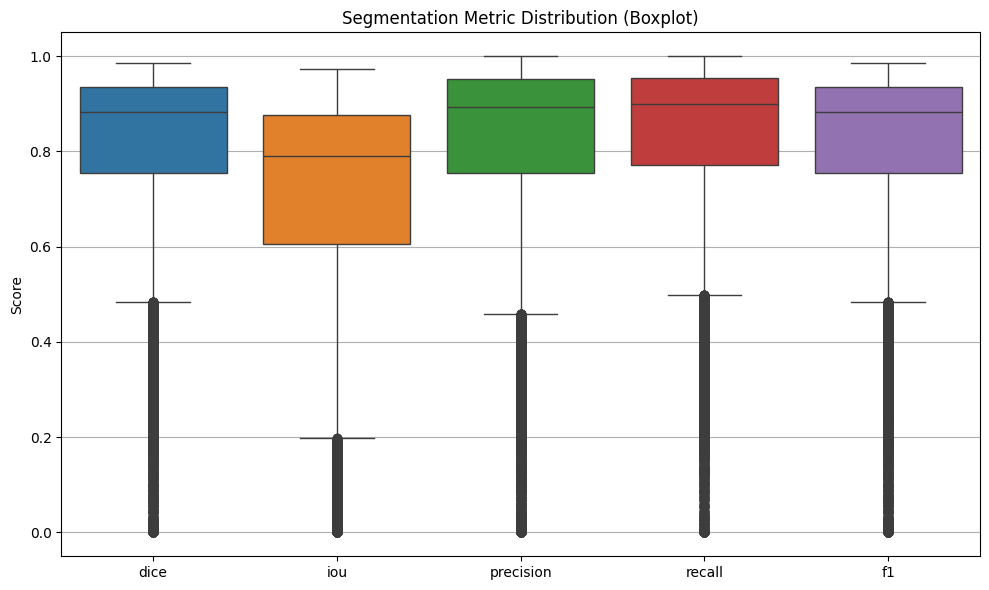

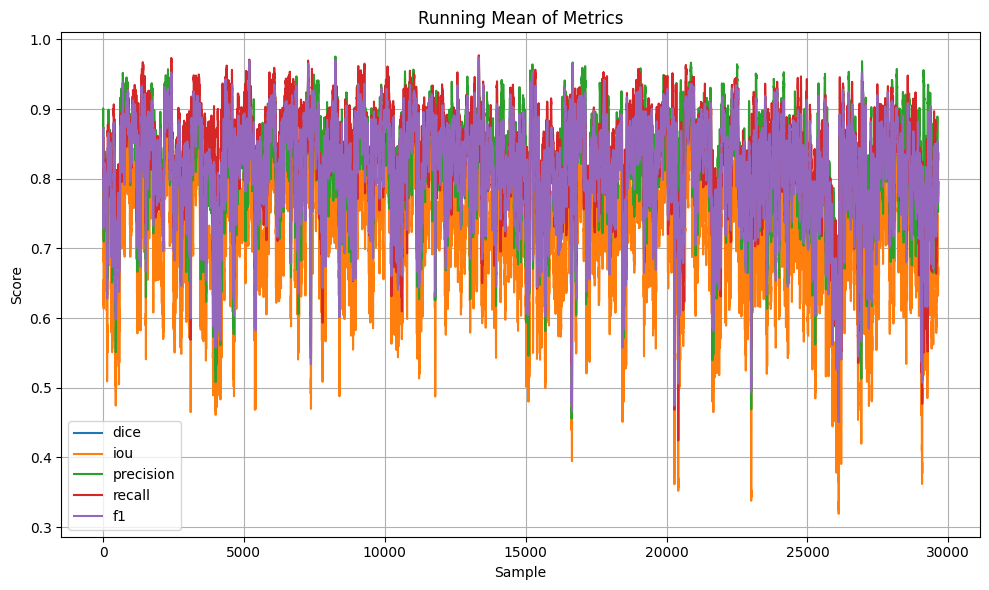

In [2]:
npy_path = "/qumulo/shared_data/aofei_summer/RegTok/source/RegTok_no_quant_abd/002-RegTok/checkpoints/segmentation_abd_eval_intermediate.npy"

data = np.load(npy_path, allow_pickle=True).item()
metrics = ["dice", "iou", "precision", "recall", "f1"]

# Boxplot for all metrics
plt.figure(figsize=(10, 6))
sns.boxplot(data=[data[m] for m in metrics])
plt.xticks(range(len(metrics)), metrics)
plt.title("Segmentation Metric Distribution (Boxplot)")
plt.ylabel("Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Lineplot for running mean of each metric
plt.figure(figsize=(10, 6))
for m in metrics:
    scores = np.array(data[m])
    running_mean = np.convolve(scores, np.ones(20)/20, mode='valid') if len(scores) > 20 else scores
    plt.plot(running_mean, label=m)
plt.title("Running Mean of Metrics")
plt.xlabel("Sample")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()